In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv(r'C:\Users\HP\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [43]:
df.shape

(200, 5)

In [44]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [45]:
df.isnull().sum().sum()

np.int64(0)

In [46]:
df.drop('CustomerID', axis=1, inplace=True)

In [47]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


In [49]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [50]:
df.describe()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [51]:
# Feature Scaling

In [52]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
scaled_data = ss.fit_transform(df)


In [53]:
# Exploratory Data Analysis (EDA)

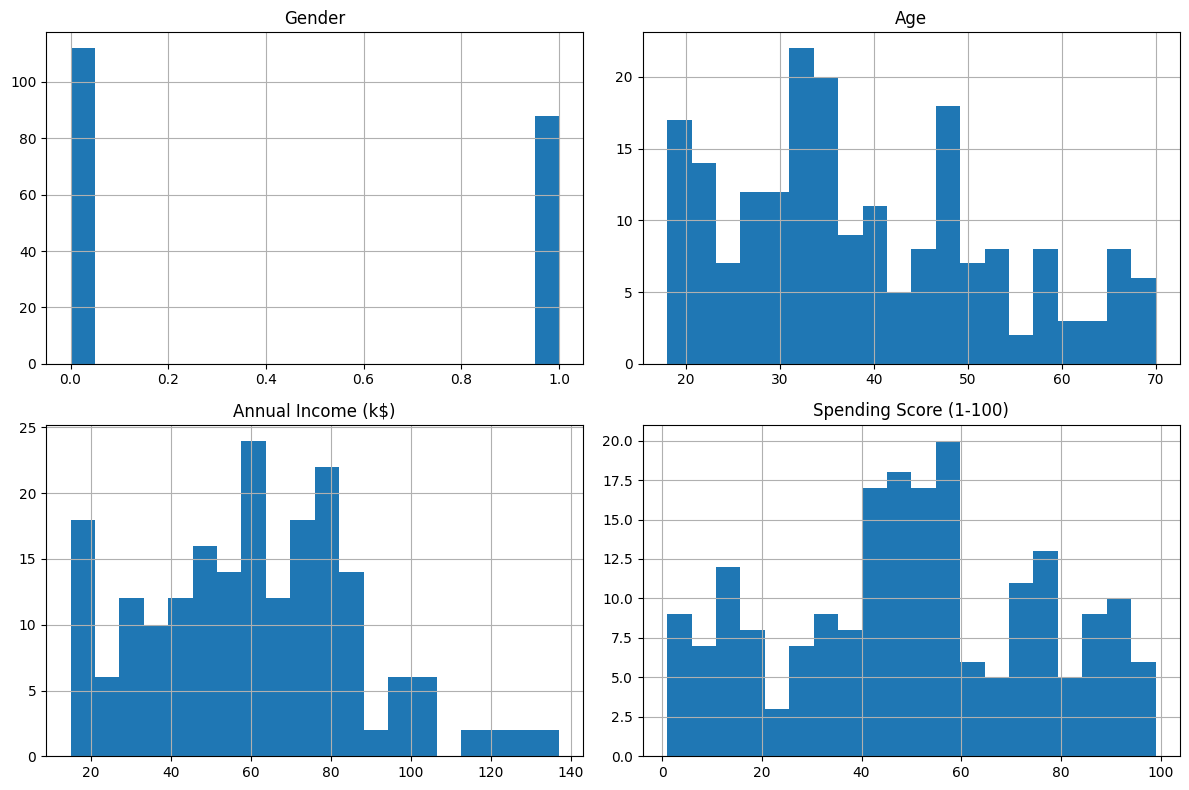

In [54]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


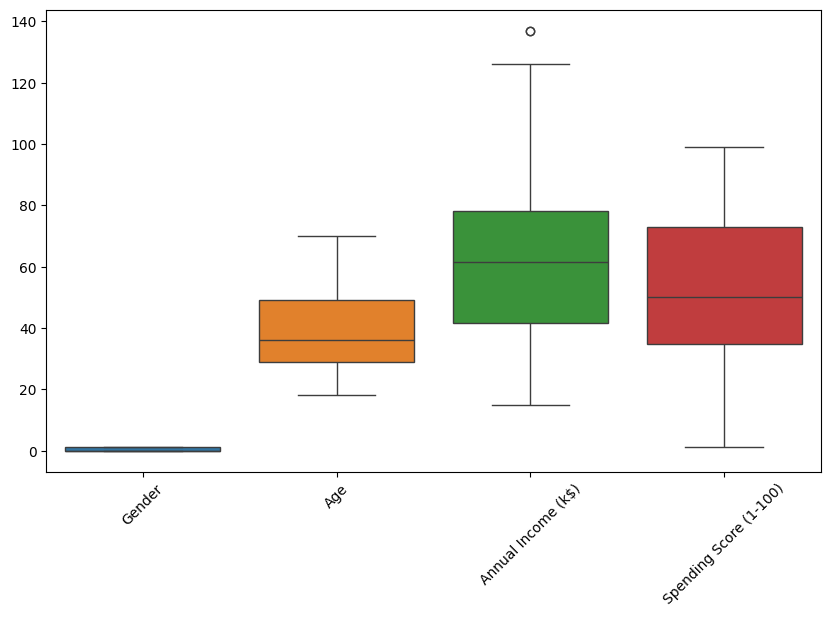

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()


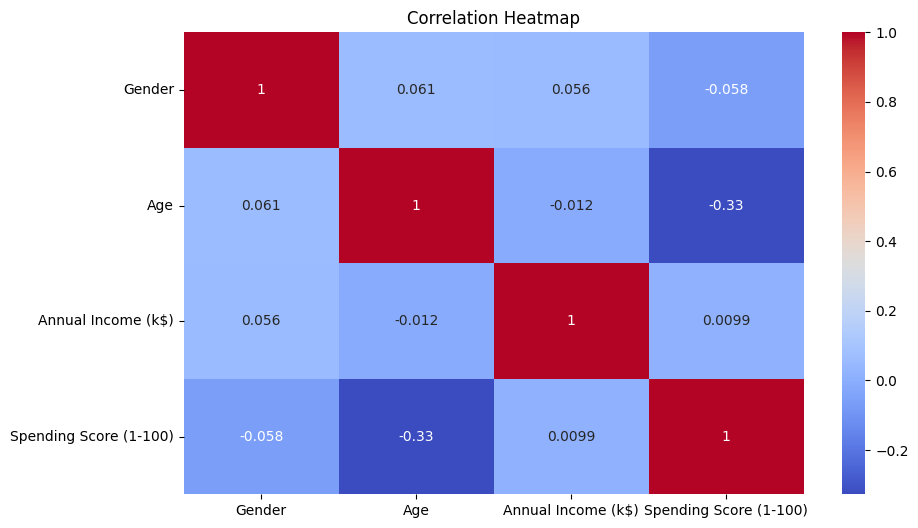

In [56]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


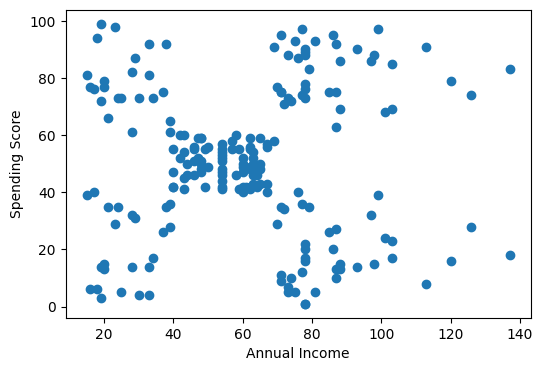

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


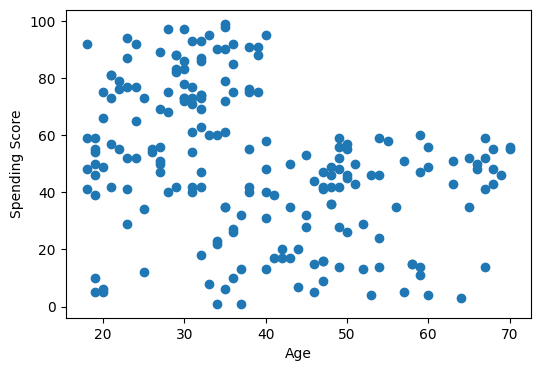

In [58]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()


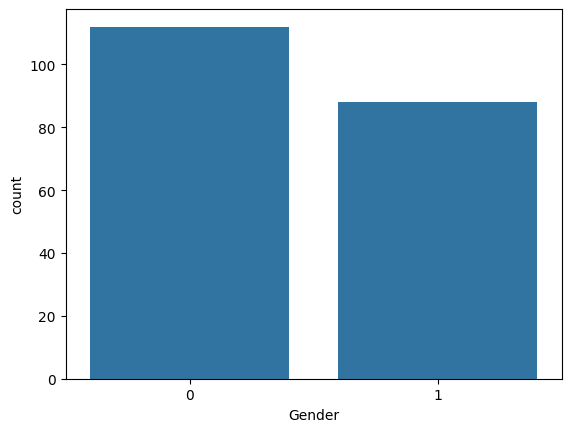

In [59]:
sns.countplot(x='Gender', data=df)
plt.show()


In [60]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


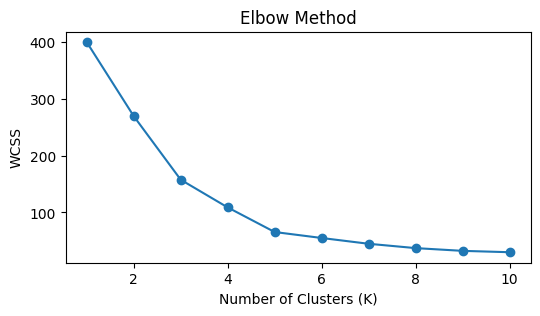

In [62]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,3))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


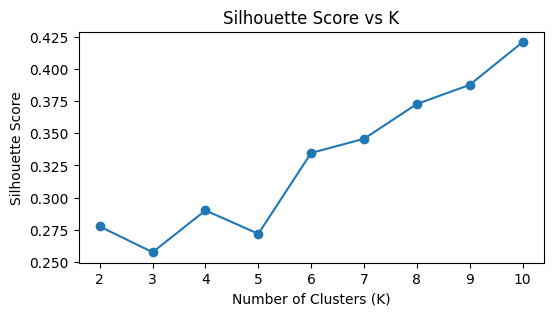

In [63]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,3))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()


In [64]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(x_scaled)


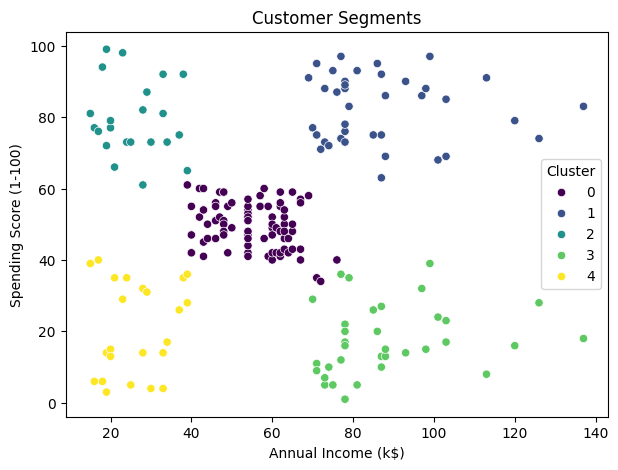

In [65]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Customer Segments")
plt.show()


In [66]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [67]:
df['Customer_Type'] = df['Cluster'].map({
    0: 'Premium',
    1: 'Regular',
    2: 'Budget',
    3: 'Careful Spenders',
    4: 'Impulse Buyers'
})


In [68]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer_Type
0,1,19,15,39,4,Impulse Buyers
1,1,21,15,81,2,Budget
2,0,20,16,6,4,Impulse Buyers
3,0,23,16,77,2,Budget
4,0,31,17,40,4,Impulse Buyers


In [69]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(x_scaled)


In [70]:
df['DBSCAN_Cluster'].value_counts()


DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64

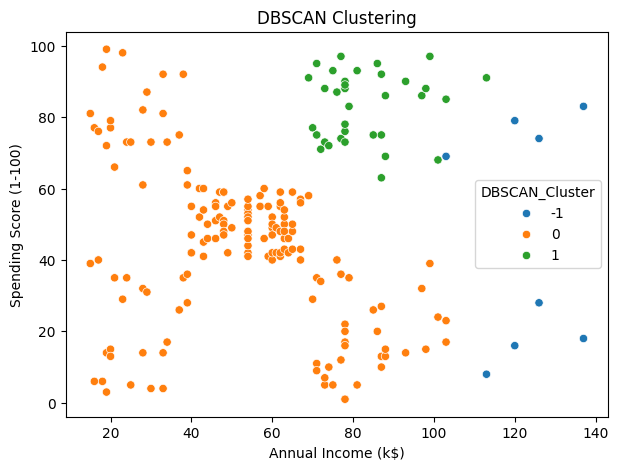

In [71]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['DBSCAN_Cluster'],
    palette='tab10'
)
plt.title("DBSCAN Clustering")
plt.show()


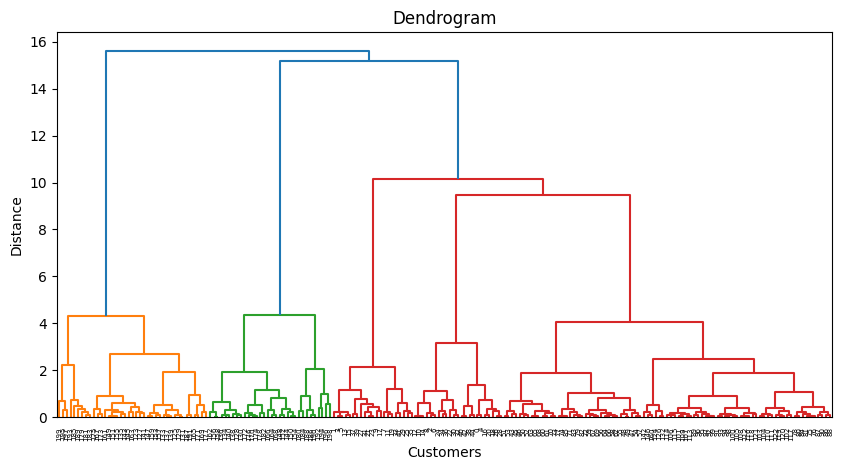

In [72]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


In [73]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['HC_Cluster'] = hc.fit_predict(x_scaled)


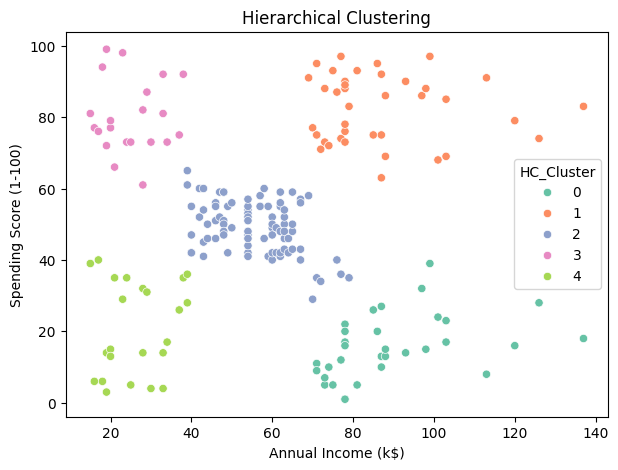

In [74]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['HC_Cluster'],
    palette='Set2'
)
plt.title("Hierarchical Clustering")
plt.show()


In [75]:
df[['Cluster', 'DBSCAN_Cluster', 'HC_Cluster']].head()


,Cluster,DBSCAN_Cluster,HC_Cluster
0,4,0,4
1,2,0,3
2,4,0,4
3,2,0,3
4,4,0,4
